# 🧠 Brain Activity Visualizer: How Does Your Brain React to Social Media?

**TRIBE v2** (Transformers for Robust, Interpretable Brain Encoding, version 2) is a Meta AI model that predicts how your brain would respond — in real time — to video content. It was trained on fMRI data from people watching thousands of hours of video, and it can now estimate which brain regions would light up when *you* watch a TikTok, a YouTube Short, or any short video clip.

This notebook walks you through uploading one or more short videos, running them through TRIBE v2, and generating beautiful, interactive brain activation maps — no coding experience required.

---

## ✅ Before You Begin — Checklist

Please confirm all of the following before running any cells:

1. **You are using Google Colab** at [colab.research.google.com](https://colab.research.google.com)
2. **Your runtime is set to A100 GPU with High RAM** — go to **Runtime → Change Runtime Type → A100 GPU** and check **High RAM**
3. **You have a free HuggingFace account** and have accepted Meta's LLaMA 3.2 license at [huggingface.co/meta-llama/Llama-3.2-3B](https://huggingface.co/meta-llama/Llama-3.2-3B)
4. **You have a HuggingFace read token** — go to your HuggingFace **Settings → Access Tokens → New Token** (select **Read** type)

> ⚠️ **Important:** This notebook requires an **A100 GPU**. A standard T4 GPU does not have enough memory and will crash. Colab Pro or Colab Pro+ is required to access A100 GPUs.

---
## Section 1 — Fix NumPy Version

Google Colab comes pre-installed with NumPy 2.x, which is incompatible with TRIBE v2. This cell downgrades NumPy to a compatible version.

**⚠️ After running this cell, you MUST restart the runtime before continuing:**
1. Go to **Runtime → Restart Runtime** (or press `Ctrl+M` then `.`)
2. Wait for the runtime to restart
3. Then continue from **Section 2** — do **not** re-run Section 1

In [ ]:
# @title Section 1 — Fix NumPy Version

import subprocess, sys

print("ℹ️  Fixing NumPy version for TRIBE v2 compatibility...")
subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "numpy"], stdout=subprocess.DEVNULL)
subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy>=1.26.4,<2.1.0", "-q"])

print()
print("=" * 60)
print("✅  NumPy fixed!")
print()
print("  👉  Now go to:  Runtime → Restart Runtime")
print("  👉  Then continue from Section 2.")
print("  👉  Do NOT re-run this cell after restarting.")
print("=" * 60)

ℹ️  Fixing NumPy version for TRIBE v2 compatibility...

✅  NumPy fixed!

  👉  Now go to:  Runtime → Restart Runtime
  👉  Then continue from Section 2.
  👉  Do NOT re-run this cell after restarting.


---
## Section 2 — Install Dependencies

This cell installs all the Python libraries needed to run TRIBE v2 and generate brain visualizations. **This may take 3–5 minutes** — please be patient and do not interrupt it.

You only need to run this once per Colab session.

In [1]:
# @title Section 2 — Install Dependencies

import subprocess, sys

print("ℹ️  Installing TRIBE v2 and required libraries...")
print("   This will take 3–5 minutes. Please wait.\n")

packages = [
    "git+https://github.com/facebookresearch/tribev2.git#egg=tribev2[plotting]",
    "gradio>=4.19.0",
    "nilearn>=0.10.3",
    "plotly>=5.18.0",
]

for pkg in packages:
    print(f"   📦 Installing: {pkg.split('#')[0]}")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"\n⚠️  Warning installing {pkg}:")
        print(result.stderr[-500:])

print()
print("✅ All libraries installed successfully!")

ℹ️  Installing TRIBE v2 and required libraries...
   This will take 3–5 minutes. Please wait.

   📦 Installing: git+https://github.com/facebookresearch/tribev2.git
   📦 Installing: gradio>=4.19.0
   📦 Installing: nilearn>=0.10.3
   📦 Installing: plotly>=5.18.0

✅ All libraries installed successfully!


---
## Section 3 — HuggingFace Authentication

TRIBE v2 uses Meta's **LLaMA 3.2** language model internally, which is a **gated model** — you need to agree to Meta's terms before downloading it.

Follow these steps to add your token to Colab Secrets (this keeps it private and secure):

1. Click the 🔑 **key icon** in the left sidebar of Colab
2. Click **"Add new secret"**
3. **Name:** `HF_TOKEN`
4. **Value:** paste your HuggingFace read token (starts with `hf_...`)
5. Toggle **"Notebook access"** to **ON**
6. Then run this cell

In [2]:
# @title Section 3 — HuggingFace Authentication

import os

try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
    if not hf_token:
        raise ValueError("Token is empty")
    os.environ['HF_TOKEN'] = hf_token
    print("✅ HuggingFace token loaded successfully!")
    print(f"   Token starts with: {hf_token[:8]}...")

except Exception as e:
    print("❌ Could not load your HuggingFace token.")
    print()
    print("   To fix this:")
    print("   1. Click the 🔑 key icon in the LEFT sidebar of Colab")
    print("   2. Click 'Add new secret'")
    print("   3. Name:  HF_TOKEN")
    print("   4. Value: your HuggingFace token (starts with hf_...)")
    print("   5. Toggle 'Notebook access' to ON")
    print("   6. Re-run this cell")
    print()
    print(f"   (Technical detail: {e})")

✅ HuggingFace token loaded successfully!
   Token starts with: hf_jUgiO...


---
## Section 4 — Pre-Download the LLaMA Language Model

TRIBE v2 uses LLaMA 3.2 to understand the semantic meaning of what's being said in your video. This model file is about **6 GB** and needs to be downloaded before inference — otherwise the model loading step can time out.

**This may take 5–10 minutes** depending on your connection speed. Grab a coffee ☕ and let it run.

In [3]:
# @title Section 4 — Pre-Download LLaMA Model

import os
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '300'

LLAMA_CACHE = '/content/tribe_cache/llama'
os.makedirs(LLAMA_CACHE, exist_ok=True)

print("ℹ️  Downloading LLaMA 3.2 (~6 GB). This will take 5–10 minutes...")
print("   Please wait and do not interrupt this cell.\n")

try:
    from huggingface_hub import snapshot_download
    snapshot_download(
        repo_id="meta-llama/Llama-3.2-3B",
        local_dir=LLAMA_CACHE,
        ignore_patterns=["*.bin"],
        token=os.environ.get('HF_TOKEN'),
    )
    print("\n✅ LLaMA model downloaded!")

except Exception as e:
    err_str = str(e)
    print("\n❌ Download failed. Here's what to check:")
    if "401" in err_str or "unauthorized" in err_str.lower():
        print("   → Your HuggingFace token is invalid or not authorized.")
        print("     Go to huggingface.co/meta-llama/Llama-3.2-3B and accept the license.")
        print("     Then re-run Section 3 to reload your token.")
    elif "403" in err_str or "gated" in err_str.lower():
        print("   → You haven't accepted Meta's license for LLaMA 3.2.")
        print("     Visit: https://huggingface.co/meta-llama/Llama-3.2-3B")
        print("     Click 'Agree and access repository' and try again.")
    elif "timeout" in err_str.lower():
        print("   → The download timed out. Re-run this cell to retry.")
    else:
        print(f"   Technical error: {err_str[:300]}")

ℹ️  Downloading LLaMA 3.2 (~6 GB). This will take 5–10 minutes...
   Please wait and do not interrupt this cell.



Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]


✅ LLaMA model downloaded!


---
## Section 5 — Load the TRIBE v2 Model

Now we load the full TRIBE v2 model, which includes **three neural encoders**:
- 🎥 **Vision encoder** — analyzes what you see in the video
- 🗣️ **Language encoder** — processes speech and on-screen text
- 🎵 **Audio encoder** — captures music, sound effects, and tone of voice

Together, these encoders use approximately **30 GB of GPU memory** — which is why an A100 is required.

**Loading takes 2–4 minutes.** Do not run any other cells while this is loading.

In [4]:
# @title Section 5 — Load TRIBE v2 Model

import os

print("ℹ️  Loading TRIBE v2 model (vision + language + audio encoders)...")
print("   This uses ~30 GB of GPU memory and takes 2–4 minutes.")
print("   Please do not run other cells while waiting.\n")

model = None

try:
    from tribev2.demo_utils import TribeModel

    model = TribeModel.from_pretrained(
        'facebook/tribev2',
        cache_folder='/content/tribe_cache'
    )

    print("\n✅ TRIBE v2 model loaded and ready!")
    print("   All three encoders (vision, language, audio) are active.")

except Exception as e:
    err_str = str(e)
    print("\n❌ Failed to load TRIBE v2 model.")

    if "CUDA out of memory" in err_str or "out of memory" in err_str.lower():
        print()
        print("   ⚠️  GPU MEMORY ERROR — You need an A100 GPU!")
        print("   To fix: Runtime → Change Runtime Type → A100 GPU + High RAM → Save")
        print("   Then re-run from Section 2.")
    elif "401" in err_str or "unauthorized" in err_str.lower():
        print("   → HuggingFace authentication failed. Re-run Section 3.")
    elif "ModuleNotFoundError" in err_str or "No module" in err_str:
        print("   → TRIBE v2 is not installed. Re-run Section 2.")
    else:
        print(f"   Technical error: {err_str[:400]}")

ℹ️  Loading TRIBE v2 model (vision + language + audio encoders)...
   This uses ~30 GB of GPU memory and takes 2–4 minutes.
   Please do not run other cells while waiting.



/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-22 12:23:35 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

2026-04-22 12:23:42 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:461: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use 


✅ TRIBE v2 model loaded and ready!
   All three encoders (vision, language, audio) are active.


---
## Section 6 — Upload Your Videos

Upload one or more MP4 videos to analyze. You can select multiple files at once (hold `Ctrl` or `Cmd`).

**Tips for great results:**
- **Format:** MP4 only (convert at [cloudconvert.com](https://cloudconvert.com) if needed)
- **Length:** 10–60 seconds is ideal
- **Content:** Videos with speech, music, and visual movement produce the most interesting maps
- **Comparison:** Uploading two contrasting videos (e.g. a fast-paced TikTok vs. a calm nature clip) reveals which brain regions are uniquely activated by each type of content

**Re-run this cell at any time to add more videos.** New uploads are appended automatically.

> 💡 **How to download TikToks/Reels:** Use [ssstik.io](https://ssstik.io) or [snapinsta.app](https://snapinsta.app) before uploading here.

In [5]:
# @title Section 6 — Upload Videos

from google.colab import files
import os

# VIDEOS is the single source of truth for this notebook.
# Each entry: {"label": "A", "path": "/content/...", "filename": "...", "preds": None, "segments": None}
# Re-running this cell appends new uploads without erasing previous ones.
if 'VIDEOS' not in dir():
    VIDEOS = []

LABEL_SEQUENCE = [chr(ord('A') + i) for i in range(26)]

print("ℹ️  Select one or more MP4 files to upload.")
print("   Hold Ctrl (Windows) or Cmd (Mac) to select multiple files at once.\n")

try:
    uploaded = files.upload()

    if not uploaded:
        print("⚠️  No files uploaded.")
        if VIDEOS:
            labels = ', '.join(v['label'] for v in VIDEOS)
            print(f"   Previously uploaded videos are still available: {labels}")
    else:
        added = 0
        for filename, data in uploaded.items():
            if not filename.lower().endswith('.mp4'):
                print(f"   ⚠️  Skipping '{filename}' — not an MP4. Convert at cloudconvert.com.")
                continue

            used_labels = {v['label'] for v in VIDEOS}
            label = next(l for l in LABEL_SEQUENCE if l not in used_labels)
            save_path = f'/content/video_{label}_{filename}'

            with open(save_path, 'wb') as f:
                f.write(data)

            size_mb = len(data) / (1024 * 1024)
            VIDEOS.append({"label": label, "path": save_path, "filename": filename,
                            "preds": None, "segments": None})

            print(f"   ✅ Video {label}: {filename} ({size_mb:.1f} MB)")
            added += 1

        if added > 0:
            labels_all = ', '.join(v['label'] for v in VIDEOS)
            print(f"\n✅ {len(VIDEOS)} video(s) ready: {labels_all}")
            print("   Continue to Section 7 to run brain predictions.")
        else:
            print("\n⚠️  No valid MP4 files were uploaded.")

except Exception as e:
    print(f"\n❌ Upload failed: {e}")
    print("   Re-run this cell and try again.")

ℹ️  Select one or more MP4 files to upload.
   Hold Ctrl (Windows) or Cmd (Mac) to select multiple files at once.



Saving Calm_tikTok.mp4 to Calm_tikTok.mp4
Saving Dance_Tiktok.mp4 to Dance_Tiktok.mp4
Saving Sledding_TikTok.mp4 to Sledding_TikTok.mp4
Saving Axe_TikTok.mp4 to Axe_TikTok.mp4
   ✅ Video A: Calm_tikTok.mp4 (1.1 MB)
   ✅ Video B: Dance_Tiktok.mp4 (2.2 MB)
   ✅ Video C: Sledding_TikTok.mp4 (2.4 MB)
   ✅ Video D: Axe_TikTok.mp4 (3.2 MB)

✅ 4 video(s) ready: A, B, C, D
   Continue to Section 7 to run brain predictions.


---
## Section 7 — Run Brain Activity Predictions

Here's what's happening under the hood:

1. TRIBE v2 processes each video frame by frame through its vision, language, and audio encoders
2. It predicts what the **fMRI BOLD signal** would look like across **20,484 points** on your brain surface
3. The predictions are mapped onto a 3D model of the human brain (called `fsaverage5`)

**Expected time:** ~1–3 minutes per video. Already-processed videos are skipped automatically if you re-run this cell.

**ℹ️ Note on hemodynamic delay:** Blood flow in the brain peaks about **5–6 seconds AFTER** a stimulus. So when we visualize the brain response at time step T=5, we are seeing the brain's reaction to what happened ~5 seconds earlier in the video — this is normal and expected.

In [6]:
# @title Section 7 — Run Brain Activity Predictions

if not VIDEOS:
    print("❌ No videos found. Please run Section 6 to upload your videos.")
elif model is None:
    print("❌ Model is not loaded. Please run Section 5 first.")
else:
    pending = [v for v in VIDEOS if v['preds'] is None]

    if not pending:
        labels = ', '.join(v['label'] for v in VIDEOS)
        print(f"✅ All {len(VIDEOS)} video(s) already have predictions: {labels}")
        print("   Continue to Section 8 to visualize.")
    else:
        print(f"ℹ️  Running TRIBE v2 on {len(pending)} video(s)...\n")

        for vid in pending:
            label    = vid['label']
            filename = vid['filename']

            print(f"🎬 Video {label}: {filename}")
            try:
                events          = model.get_events_dataframe(video_path=vid['path'])
                preds, segments = model.predict(events=events)
                vid['preds']    = preds
                vid['segments'] = segments
                print(f"   ✅ Done — {preds.shape[1]} cortical locations × {preds.shape[0]} time steps\n")

            except Exception as e:
                err_str = str(e)
                print(f"   ❌ Failed on Video {label}.")
                if "CUDA out of memory" in err_str:
                    print("      ⚠️  GPU out of memory. Switch to A100 GPU and restart from Section 2.")
                    break
                else:
                    print(f"      Technical error: {err_str[:300]}")
                    print("      Skipping this video and continuing.\n")

        succeeded = [v for v in VIDEOS if v['preds'] is not None]
        if succeeded:
            print(f"✅ Predictions complete for: {', '.join(v['label'] for v in succeeded)}")
            print("   🧠 Ready to visualize! Continue to Section 8.")

ℹ️  Running TRIBE v2 on 4 video(s)...

🎬 Video A: Calm_tikTok.mp4


Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in /content/video_A_Calm_tikTok.wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  5.37it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


MoviePy - Done.


...

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[12:34:18 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-04-22 12:34:22 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 7.1s at 30.0fps, shape (720, 1280)):
/content/video_D_Axe_TikTok.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 7.1s at 30.0fps, shape (720, 1280)):
/content/video_D_Axe_TikTok.mp4
Encoding video:   0%|          | 0/14 [00:00<?, ?it/s]2026-04-22 12:34:25 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (14, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (14, 20, 1408)
Encoding video: 100%|██████████| 14/14 [00:44<00:00,  3.18s/it]
[12:35:07 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-22 12:35:07 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[12:35:07 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: Us

   ✅ Done — 20484 cortical locations × 8 time steps

✅ Predictions complete for: A, B, C, D
   🧠 Ready to visualize! Continue to Section 8.


---
## Section 8 — Brain Heatmaps

This section generates a **color-coded flat map** of each brain surface:
- 🔴 **Warm colors (red/yellow)** = high predicted brain activity
- 🔵 **Cool colors (blue)** = low predicted brain activity

We look at time step **T=5** to account for the ~5-second hemodynamic delay.

If you uploaded multiple videos, all maps are generated on a **shared color scale** and arranged in a comparison grid so you can directly compare activation levels across clips.

ℹ️  Fetching brain surface template (fsaverage5)...
ℹ️  Generating heatmaps for 4 video(s) (shared color scale)...



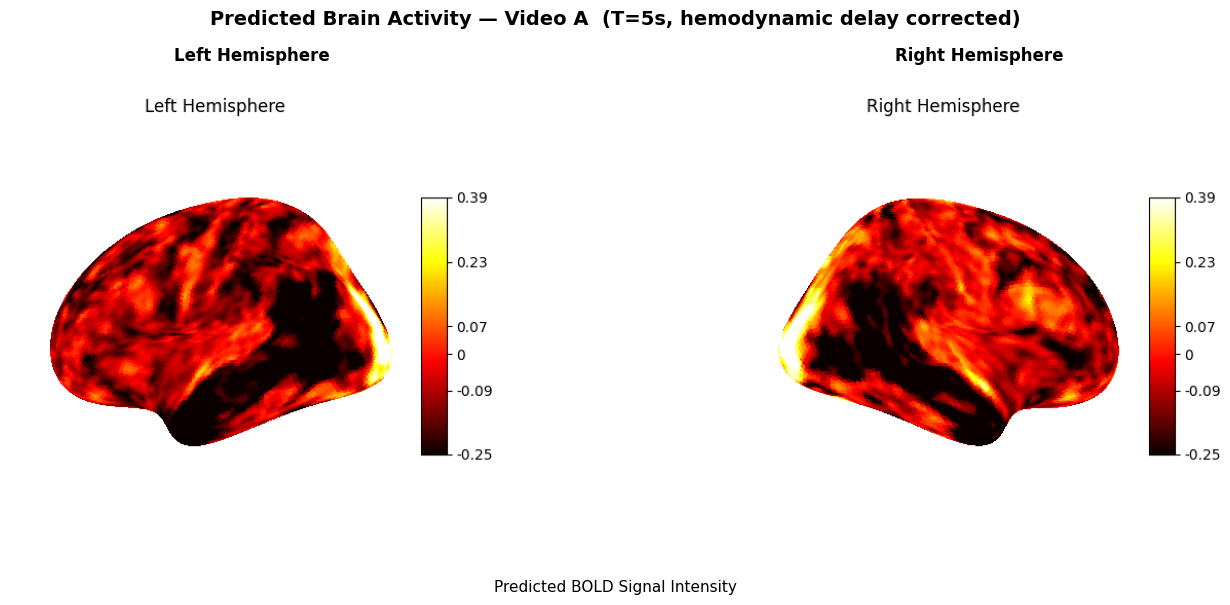

   ✅ Video A heatmap saved: /content/brain_heatmap_A.png


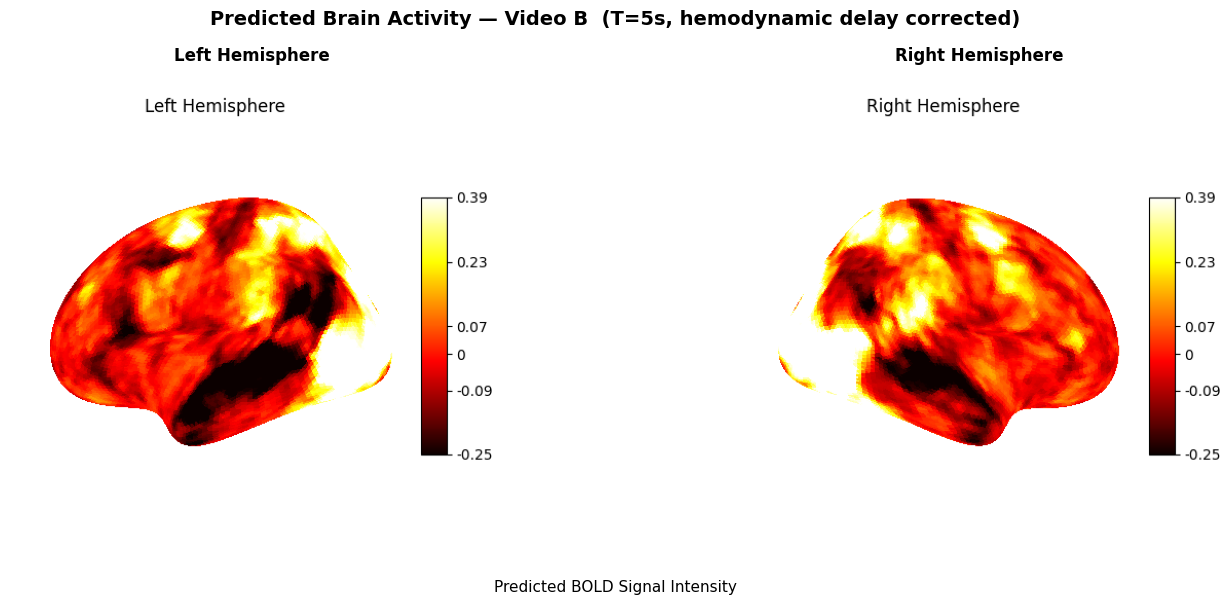

   ✅ Video B heatmap saved: /content/brain_heatmap_B.png


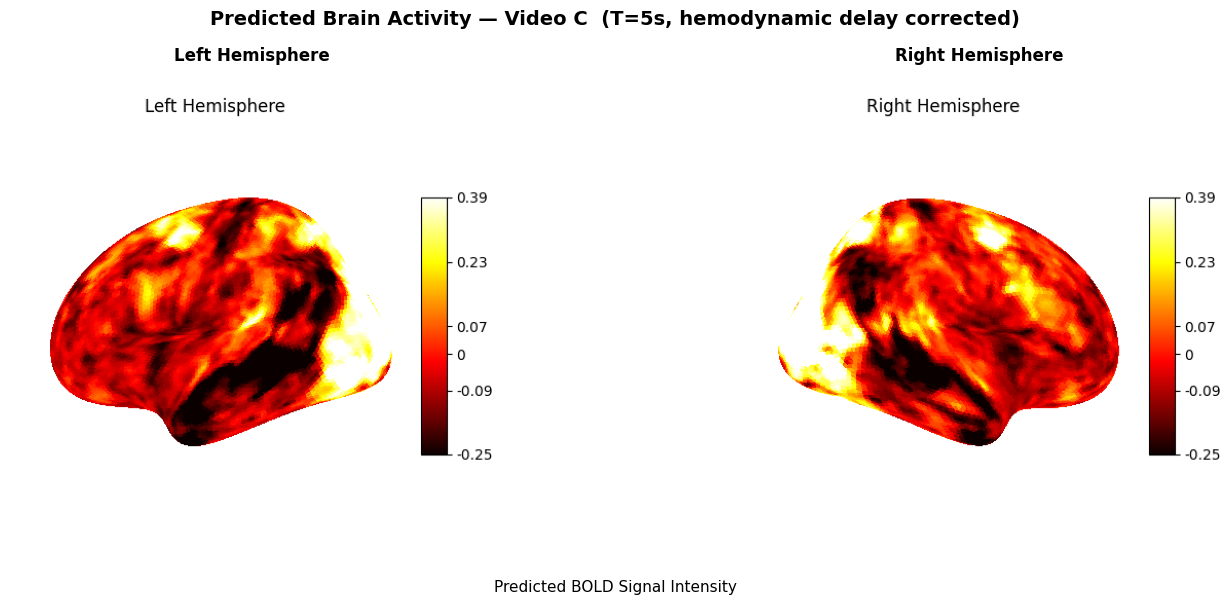

   ✅ Video C heatmap saved: /content/brain_heatmap_C.png


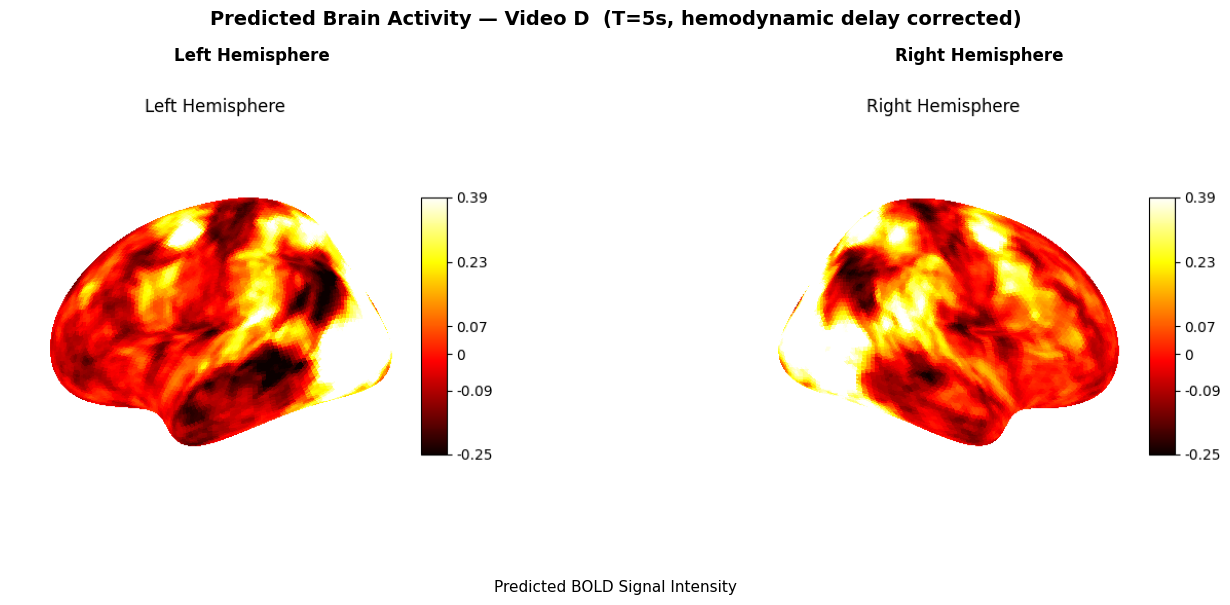

   ✅ Video D heatmap saved: /content/brain_heatmap_D.png

ℹ️  Building comparison grid...


/tmp/ipykernel_2220/4269707656.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


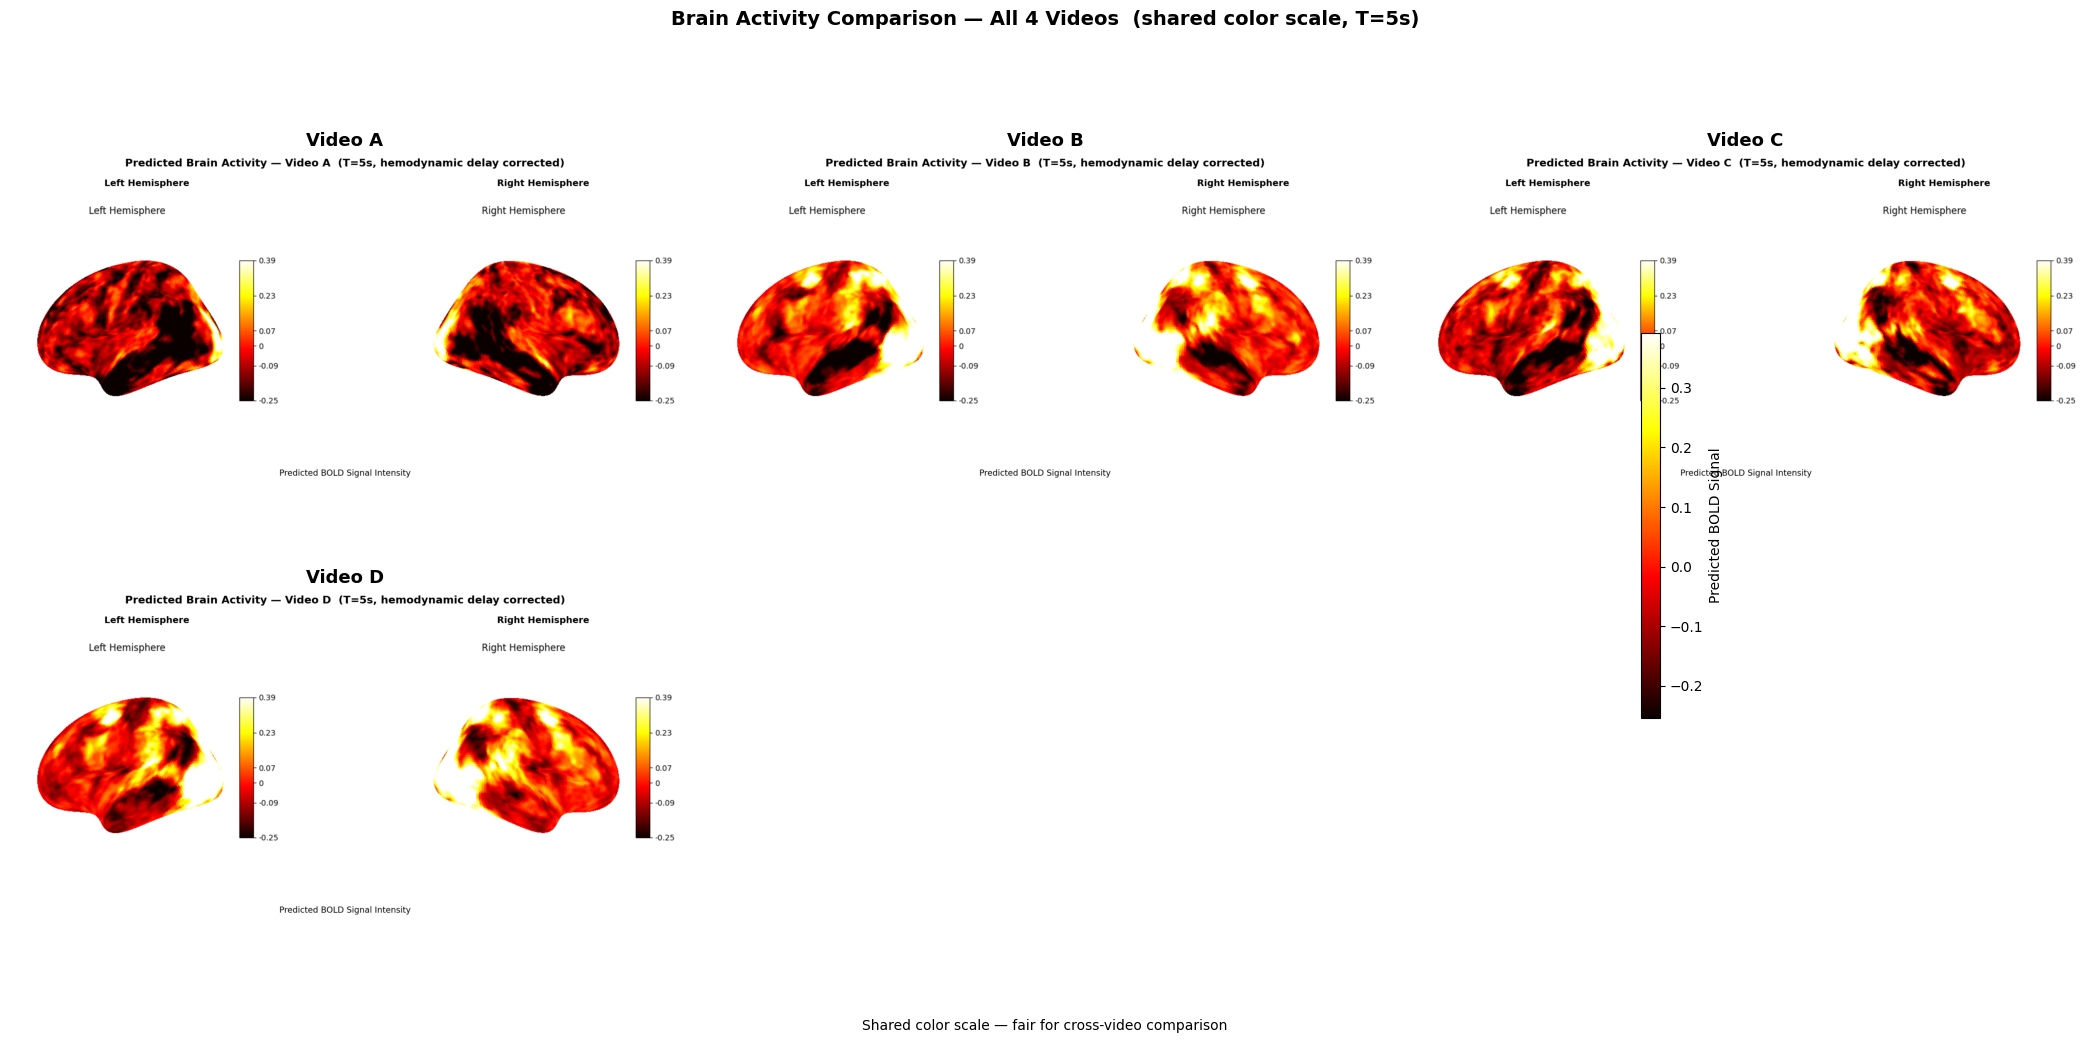


✅ Comparison grid saved: /content/brain_grid_comparison.png


In [7]:
# @title Section 8 — Brain Heatmaps

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import os

ready = [v for v in VIDEOS if v['preds'] is not None]

if not ready:
    print("❌ No predictions found. Please run Section 7 first.")
else:
    try:
        from nilearn import datasets, plotting

        print("ℹ️  Fetching brain surface template (fsaverage5)...")
        fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')

        T      = 5
        N_VERTS = 10242  # fsaverage5 vertices per hemisphere

        # Compute a shared color scale across all videos for fair comparison
        all_vals = np.concatenate([v['preds'][T, :N_VERTS] for v in ready])
        vmin = float(np.percentile(all_vals, 5))
        vmax = float(np.percentile(all_vals, 95))

        print(f"ℹ️  Generating heatmaps for {len(ready)} video(s) (shared color scale)...\n")

        tmp_paths = []  # Used to build the comparison grid below

        for vid in ready:
            label      = vid['label']
            data_left  = vid['preds'][T, :N_VERTS]
            data_right = vid['preds'][T, N_VERTS:N_VERTS * 2]

            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            fig.suptitle(
                f'Predicted Brain Activity — Video {label}  (T={T}s, hemodynamic delay corrected)',
                fontsize=14, fontweight='bold'
            )

            for ax, hemi, data, title in zip(
                axes,
                ['left', 'right'],
                [data_left, data_right],
                ['Left Hemisphere', 'Right Hemisphere']
            ):
                tmp = f'/content/_tmp_{label}_{hemi}.png'
                plotting.plot_surf_stat_map(
                    surf_mesh=fsaverage[f'infl_{hemi}'], stat_map=data, hemi=hemi,
                    view='lateral', cmap='hot', vmin=vmin, vmax=vmax,
                    colorbar=True, title=title, output_file=tmp,
                )
                ax.imshow(plt.imread(tmp))
                ax.axis('off')
                ax.set_title(title, fontsize=12, fontweight='bold')

            fig.text(0.5, 0.01, 'Predicted BOLD Signal Intensity', ha='center', fontsize=11)
            plt.tight_layout()
            out = f'/content/brain_heatmap_{label}.png'
            plt.savefig(out, dpi=150, bbox_inches='tight')
            plt.show()
            tmp_paths.append((label, f'/content/brain_heatmap_{label}.png'))
            print(f"   ✅ Video {label} heatmap saved: {out}")

        # Comparison grid (only when there are multiple videos)
        if len(ready) > 1:
            print("\nℹ️  Building comparison grid...")
            n     = len(ready)
            ncols = min(n, 3)
            nrows = (n + ncols - 1) // ncols

            fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
            axes_flat = np.array(axes).reshape(-1)

            for ax, (label, path) in zip(axes_flat, tmp_paths):
                ax.imshow(mpimg.imread(path))
                ax.axis('off')
                ax.set_title(f'Video {label}', fontsize=13, fontweight='bold')

            for ax in axes_flat[len(ready):]:
                ax.set_visible(False)

            sm = plt.cm.ScalarMappable(cmap='hot', norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            fig.colorbar(sm, ax=axes_flat.tolist(), shrink=0.5, pad=0.02, label='Predicted BOLD Signal')
            fig.suptitle(
                f'Brain Activity Comparison — All {n} Videos  (shared color scale, T={T}s)',
                fontsize=14, fontweight='bold', y=1.01
            )
            fig.text(0.5, -0.01, 'Shared color scale — fair for cross-video comparison',
                     ha='center', fontsize=10)
            plt.tight_layout()
            plt.savefig('/content/brain_grid_comparison.png', dpi=150, bbox_inches='tight')
            plt.show()
            print("\n✅ Comparison grid saved: /content/brain_grid_comparison.png")

        # Clean up temp files
        for f_name in os.listdir('/content'):
            if f_name.startswith('_tmp_'):
                os.remove(f'/content/{f_name}')

    except Exception as e:
        print(f"\n❌ Visualization failed: {e}")
        print("   Make sure Section 7 ran successfully and nilearn is installed (Section 2).")

---
## Section 9 — Interactive 3D Brain Viewer

This cell creates an **interactive 3D brain** for each video that you can:
- 🖱️ **Rotate** by clicking and dragging
- 🔍 **Zoom** with your scroll wheel
- 🎨 **See warm/cool color gradients** across the brain surface

All brains use the same shared color scale so activation levels are directly comparable.

In [8]:
# @title Section 9 — Interactive 3D Brain Viewer

from IPython.display import display
import numpy as np

ready = [v for v in VIDEOS if v['preds'] is not None]

if not ready:
    print("❌ No predictions found. Please run Section 7 first.")
else:
    try:
        from nilearn import datasets, plotting

        fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')
        T       = 5
        N_VERTS = 10242

        all_vals = np.concatenate([v['preds'][T, :N_VERTS] for v in ready])
        vmin = float(np.percentile(all_vals, 5))
        vmax = float(np.percentile(all_vals, 95))

        print("ℹ️  Rendering interactive 3D brain viewer(s)...\n")

        for vid in ready:
            print(f"🧠 Video {vid['label']} — left hemisphere, lateral view:")
            widget = plotting.view_surf(
                surf_mesh=fsaverage['infl_left'],
                surf_map=vid['preds'][T, :N_VERTS],
                cmap='hot', vmin=vmin, vmax=vmax,
                symmetric_cmap=False,
                title=f"Video {vid['label']} — Predicted Brain Activity (T={T}s)",
            )
            display(widget)
            print()

        print("✅ Use your mouse to rotate and zoom each brain above!")

    except Exception as e:
        print(f"\n❌ Interactive visualization failed: {e}")
        print("   Your static heatmaps from Section 8 are still saved at /content/.")

Output hidden; open in https://colab.research.google.com to view.

---
## Section 10 — Difference Maps *(2+ videos required)*

This is the most scientifically interesting visualization: **difference maps** showing exactly which brain regions respond *differently* across your videos.

Each video is compared against Video A:
- 🔴 **Red regions** = more active for that video
- 🔵 **Blue regions** = more active for Video A
- ⬜ **Neutral regions** = similar activity in both

If you only uploaded one video, this section will skip automatically.

In [9]:
# @title Section 10 — Difference Maps

from IPython.display import display
import numpy as np

ready = [v for v in VIDEOS if v['preds'] is not None]

if len(ready) < 2:
    print("ℹ️  Only one video available — difference maps require at least two videos.")
    print("   Upload a second video in Section 6 and re-run from Section 7.")
else:
    try:
        from nilearn import datasets, plotting

        fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')
        T       = 5
        N_VERTS = 10242

        base      = ready[0]
        base_data = base['preds'][T, :N_VERTS]

        print(f"ℹ️  Comparing all videos against Video {base['label']} (baseline)...\n")

        for vid in ready[1:]:
            label   = vid['label']
            diff    = vid['preds'][T, :N_VERTS] - base_data
            abs_max = float(np.percentile(np.abs(diff), 95))

            if abs_max == 0:
                print(f"⚠️  Video {label}: difference is zero — these two videos may be identical.")
                continue

            print(f"🧠 Video {label} − Video {base['label']}  "
                  f"(red = {label} more active  |  blue = {base['label']} more active):")

            widget = plotting.view_surf(
                surf_mesh=fsaverage['infl_left'],
                surf_map=diff,
                cmap='RdBu_r', vmin=-abs_max, vmax=abs_max,
                symmetric_cmap=True,
                title=(f"Video {label} − Video {base['label']}  |  "
                       f"Red = {label} more active  |  Blue = {base['label']} more active"),
            )
            display(widget)
            print()

        print("✅ All difference maps rendered above.")

    except Exception as e:
        print(f"\n❌ Difference maps failed: {e}")
        print("   Make sure all video predictions completed successfully in Section 7.")

Output hidden; open in https://colab.research.google.com to view.

---
## Section 11 — Export Results

This cell saves all results and downloads them to your computer.

**What you'll receive:**
- 🖼️ `brain_heatmap_A.png`, `brain_heatmap_B.png`, ... — static heatmaps per video
- 🖼️ `brain_grid_comparison.png` — side-by-side grid *(if 2+ videos)*
- 📊 `brain_predictions_A.npy`, `brain_predictions_B.npy`, ... — raw prediction arrays for re-analysis in Python

Files download automatically via your browser.

In [10]:
# @title Section 11 — Export Results

import numpy as np, os
from google.colab import files

ready = [v for v in VIDEOS if v['preds'] is not None]

if not ready:
    print("❌ No predictions to export. Please run Section 7 first.")
else:
    try:
        downloads = []

        print("ℹ️  Saving prediction arrays...")
        for vid in ready:
            label    = vid['label']
            npy_path = f'/content/brain_predictions_{label}.npy'
            np.save(npy_path, vid['preds'])
            print(f"   ✅ Saved: brain_predictions_{label}.npy")
            downloads.append(npy_path)

        print()
        print("ℹ️  Queuing image files...")

        for vid in ready:
            label = vid['label']
            path  = f'/content/brain_heatmap_{label}.png'
            if os.path.exists(path):
                downloads.insert(0, path)
                print(f"   ✅ brain_heatmap_{label}.png")
            else:
                print(f"   ⚠️  brain_heatmap_{label}.png not found — run Section 8 first.")

        grid_path = '/content/brain_grid_comparison.png'
        if os.path.exists(grid_path):
            downloads.insert(0, grid_path)
            print("   ✅ brain_grid_comparison.png")

        print()
        print("ℹ️  Downloading files to your computer...")
        print("   (Your browser may ask for permission to download multiple files.)\n")

        for path in downloads:
            files.download(path)

        fnames = [os.path.basename(p) for p in downloads]
        print(f"✅ {len(downloads)} file(s) downloaded: {', '.join(fnames)}")

    except Exception as e:
        print(f"\n❌ Export failed: {e}")
        print("   You can also manually download from the 📁 file browser in the left sidebar.")

ℹ️  Saving prediction arrays...
   ✅ Saved: brain_predictions_A.npy
   ✅ Saved: brain_predictions_B.npy
   ✅ Saved: brain_predictions_C.npy
   ✅ Saved: brain_predictions_D.npy

ℹ️  Queuing image files...
   ✅ brain_heatmap_A.png
   ✅ brain_heatmap_B.png
   ✅ brain_heatmap_C.png
   ✅ brain_heatmap_D.png
   ✅ brain_grid_comparison.png

ℹ️  Downloading files to your computer...
   (Your browser may ask for permission to download multiple files.)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 9 file(s) downloaded: brain_grid_comparison.png, brain_heatmap_D.png, brain_heatmap_C.png, brain_heatmap_B.png, brain_heatmap_A.png, brain_predictions_A.npy, brain_predictions_B.npy, brain_predictions_C.npy, brain_predictions_D.npy


---
## Section 12 — What Did You See? A Guide to Reading Your Brain Map

Your brain map shows predicted activation across the entire cortex. Here's a plain-English guide to what different regions mean:

---

### 🎥 Visual Cortex *(occipital lobe — back of the brain)*
This is almost always the brightest region for any video. It processes everything you *see*: movement, color, faces, and scene complexity. Fast cuts and flashing effects tend to drive very high activation here.

---

### 🎵 Auditory Cortex *(temporal lobe — sides of the brain)*
This region responds to speech, music, and sound. The left temporal lobe tends to process language; the right is more involved in music and tone.

---

### 💭 Default Mode Network *(medial prefrontal cortex + posterior cingulate — center of the brain)*
Associated with **social cognition** — thinking about other people's feelings, intentions, and relationships. More active during emotionally engaging or relatable content compared to non-social content.

---

### ⚡ Reward Circuits *(ventral striatum — deep, central brain)*
Linked to **dopamine-driven engagement** and reward processing. High-stimulation content tends to drive more activity here than calm or instructional content.

---

> **⚠️ Important note:** These predictions are **population averages** derived from fMRI data collected across many people. They represent what a *typical person* statistically shows — they are **not** a scan of your individual brain. Your personal response may differ based on attention, mood, prior experiences, and individual neurobiology.

---
## Section 13 — Troubleshooting

| Problem | Fix |
|---|---|
| `CUDA out of memory` | Switch to **A100 GPU** in **Runtime → Change Runtime Type**. A T4 is not sufficient. |
| `HF_TOKEN not found` | Re-add your token in the 🔑 **Secrets** panel (left sidebar), make sure "Notebook access" is ON, then re-run Section 3. |
| `401 Unauthorized` from HuggingFace | Accept the LLaMA 3.2 license at [huggingface.co/meta-llama/Llama-3.2-3B](https://huggingface.co/meta-llama/Llama-3.2-3B), then re-run Section 4. |
| Model takes forever to load | This is normal — TRIBE v2 loads ~28–30 GB of weights. Wait up to **5 minutes** before assuming something is wrong. |
| Video upload fails | Ensure your file is `.mp4` format and under **500 MB**. Convert at [cloudconvert.com](https://cloudconvert.com) if needed. |
| Brain map is entirely one color | Try a **longer video** (at least 15–20 seconds). Very short clips may not produce enough variation. |
| `RuntimeError` after restarting | Re-run **all cells from Section 2 onward**. Do not re-run Section 1 after restarting. |
| `ModuleNotFoundError: tribev2` | Re-run Section 2 to reinstall dependencies. |
| Interactive brain widget doesn't display | Try **Runtime → Restart and Run All** from Section 2. Your static PNGs from Section 8 are still at `/content/`. |
| Download doesn't start | In the Colab left sidebar, click the 📁 folder icon, find your files, and right-click → Download manually. |

---

**Still stuck?** The most common root cause is running on a T4 GPU instead of an A100. When in doubt: **Runtime → Change Runtime Type → A100 GPU + High RAM → Save**, then **Runtime → Restart and Run All**.